<a href="https://colab.research.google.com/github/saumya-saini/Yulu-Bike-Demand-Analysis/blob/main/Yulu_Hypothesis_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving yulu.csv to yulu.csv


In [3]:
import pandas as pd
df = pd.read_csv('yulu.csv')
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [ ]:
df.shape

(10886, 12)

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
df.dtypes

,0
datetime,object
season,int64
holiday,int64
workingday,int64
weather,int64
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


In [ ]:
df.nunique()

,0
datetime,10886
season,4
holiday,2
workingday,2
weather,4
temp,49
atemp,60
humidity,89
windspeed,28
casual,309


In [4]:
# CONVERTING CATEGORICAL ATTRIBUTES TO CATEGORY
df['season'] = df['season'].astype('category')
df['holiday'] = df['holiday'].astype('category')
df['workingday'] = df['workingday'].astype('category')
df['weather'] = df['weather'].astype('category')
df['datetime'] = pd.to_datetime(df['datetime'])
# df['datetime'] = pd.to_datetime(df['datetime'], format='%d-%m-%Y %H:%M:%S')

In [ ]:
# CONVERTING CATEGORICAL ATTRIBUTES TO CATEGORY
# categorical_attributes = ['season', 'holiday', 'workingday', 'weather']
# df[categorical_attributes] = df[categorical_attributes].astype('category')
# df['datetime'] = pd.to_datetime(df['datetime'])

In [ ]:
# EXTRACTION OF DATE TIME
df['datetime'] = pd.to_datetime(df['datetime'], format= '%d-%m-%Y %H, %M, %S')
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek

In [ ]:
df.dtypes

,0
datetime,datetime64[ns]
season,category
holiday,category
workingday,category
weather,category
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


In [ ]:
df.describe()

,datetime,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
min,2011-01-01 00:00:00,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-02 07:15:00,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,2012-01-01 20:30:00,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,2012-07-01 12:45:00,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,2012-12-19 23:00:00,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000
std,NaN,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454


In [ ]:
# MISSING VALUES
missing = pd.DataFrame({
    'Missing Values':df.isnull().sum(),
    'Missing %': df.isnull().sum()/len(df)*100
}).sort_values(by = 'Missing %', ascending = False)
missing

,Missing Values,Missing %
datetime,0,0.0
season,0,0.0
holiday,0,0.0
workingday,0,0.0
weather,0,0.0
temp,0,0.0
atemp,0,0.0
humidity,0,0.0
windspeed,0,0.0
casual,0,0.0


 ⬆️ No missing values found

In [ ]:
df.duplicated().sum()

np.int64(0)

⬆️ No duplicates found

In [ ]:
df.nunique()

,0
datetime,10886
season,4
holiday,2
workingday,2
weather,4
temp,49
atemp,60
humidity,89
windspeed,28
casual,309


In [ ]:
# VALUE COUNT OF SEASON
df['season'].value_counts()

# 1: spring
# 2: summer
# 3: fall
# 4: winter

,count
season,
4,2734
2,2733
3,2733
1,2686


In [ ]:
# VALUE COUNT OF HOLIDAY
df['holiday'].value_counts()

# 0: Not a holiday (regular day)
# 1: Holiday

,count
holiday,
0,10575
1,311


In [ ]:
# VALUE COUNT OF WORKING DAY
df['workingday'].value_counts()

# 1: Working day (not weekend and not holiday)
# 0: Non-working day (weekend or holiday)

,count
workingday,
1,7412
0,3474


In [ ]:
# VALUE COUNT OF WEATHER
df['weather'].value_counts()

# 1: Clear, Few clouds, partly cloudy
# 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
# 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
# 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

,count
weather,
1,7192
2,2834
3,859
4,1


# Univariate Analysis (Categorical)

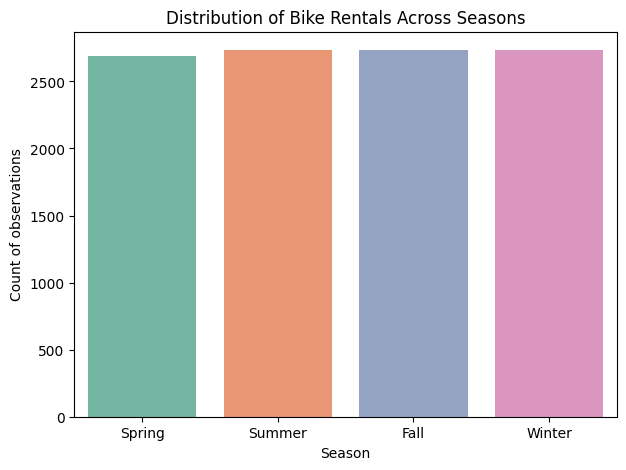

In [5]:
# SEASON DISTRIBUTION
df['season_label'] = df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}) #Changed labels of Season

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.countplot(x='season_label', data = df, palette = 'Set2', hue='season_label', legend=False )
plt.xlabel('Season')
plt.ylabel('Count of observations')
plt.title('Distribution of Bike Rentals Across Seasons')
plt.show()

Observation: The dataset is fairly evenly distributed across all seasons, indicating no significant seasonal bias in data collection.

In [6]:
df['season_label'].value_counts()

,count
season_label,
Winter,2734
Summer,2733
Fall,2733
Spring,2686


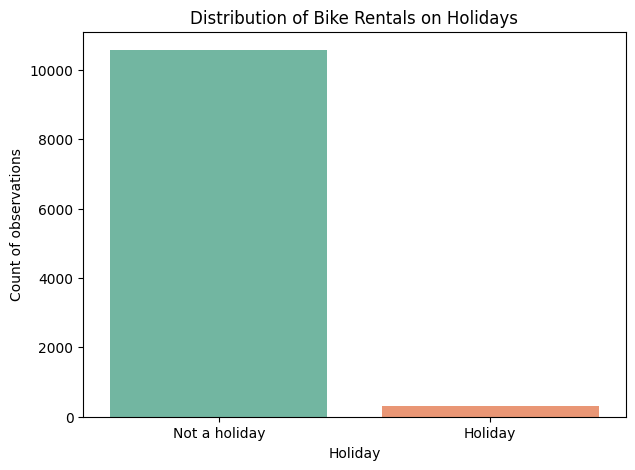

In [7]:
# HOLIDAY DISTRIBUTION
df['holiday_label'] = df['holiday'].map({0: 'Not a holiday', 1: 'Holiday'}) # Changed labels for holiday

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.countplot(x = 'holiday_label', data = df, palette = 'Set2', hue='holiday_label', legend=False)
plt.xlabel('Holiday')
plt.ylabel('Count of observations')
plt.title('Distribution of Bike Rentals on Holidays')
plt.show()

Observation: The dataset is dominated by non-holiday observations, with very few records corresponding to holidays.

In [ ]:
df['holiday_label'].value_counts()

,count
holiday_label,
Not a holiday,10575
Holiday,311


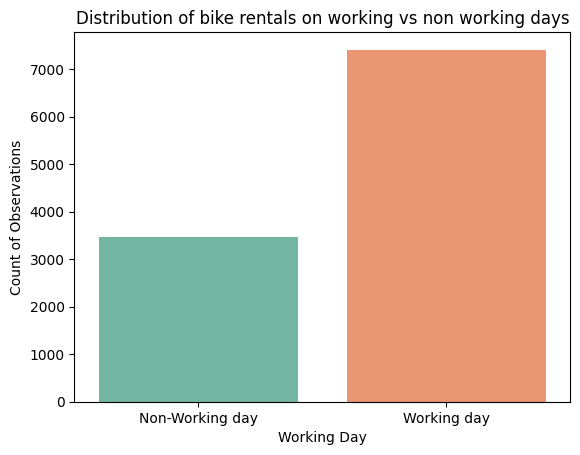

In [8]:
# WORKING DAY DISTRIBUTION
# 1: Working day (not weekend and not holiday)
# 0: Non-working day (weekend or holiday)
df['workingday_label'] = df['workingday'].map({0: 'Non-Working day', 1: 'Working day'})

import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x = 'workingday_label', data = df, palette = 'Set2', hue='workingday_label', legend=False)
plt.xlabel('Working Day')
plt.ylabel('Count of Observations')
plt.title('Distribution of bike rentals on working vs non working days')
plt.show()

Observation: Most observations correspond to working days, suggesting that the dataset mainly captures regular commuting patterns.

In [ ]:
df['workingday_label'].value_counts()

,count
workingday_label,
Working day,7412
Non-Working day,3474


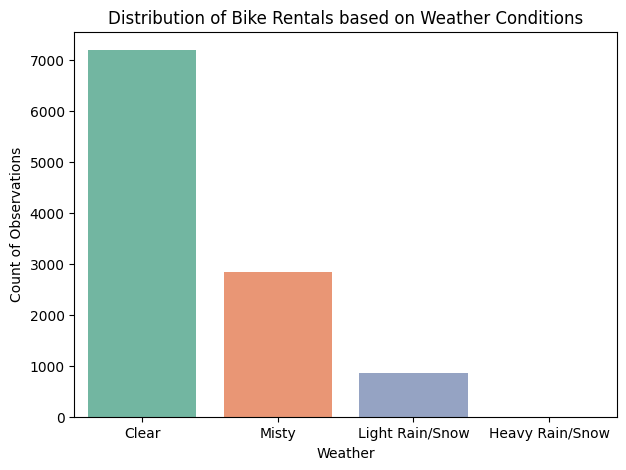

In [9]:
# WEATHER DISTRIBUTION
df['weather_label'] = df['weather'].map({1: 'Clear', 2: 'Misty', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'})

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.countplot(x = 'weather_label', data = df, palette = 'Set2', hue='weather_label', legend=False)
plt.xlabel('Weather')
plt.ylabel('Count of Observations')
plt.title('Distribution of Bike Rentals based on Weather Conditions')
plt.show()

Observation: Majority of observations fall under clear and partly cloudy weather conditions, while severe weather conditions are rare in the dataset.

In [ ]:
df['weather_label'].value_counts()

,count
weather_label,
Clear,7192
Misty,2834
Light Rain/Snow,859
Heavy Rain/Snow,1


# Univariate Analysis (Continuous)

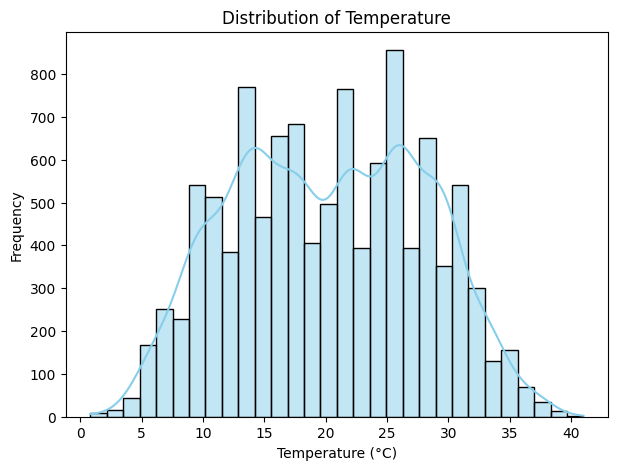

In [10]:
# TEMPERATURE (°C) DISTRIBUTION
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.histplot(x='temp', data = df, bins = 30, kde=True, color='skyblue')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.title('Distribution of Temperature')
plt.show()

Observation: Temperature shows a roughly normal distribution with most values concentrated in the moderate range.

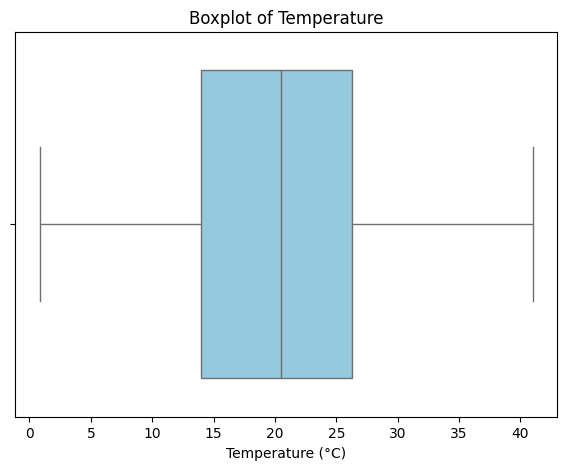

In [8]:
# OUTLIER DETECTION (TEMPERATURE)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.boxplot(x=df['temp'], color = 'skyblue')
plt.xlabel('Temperature (°C)')
plt.title("Boxplot of Temperature")
plt.show()

Obsservation:

1.) Temperature is centered around ~20°C, with most values between ~14°C and ~26°C, indicating moderate variation.

2.) The overall range is wide (about ~1°C to ~41°C), showing diverse temperature conditions. The distribution appears fairly symmetric with no significant outliers.

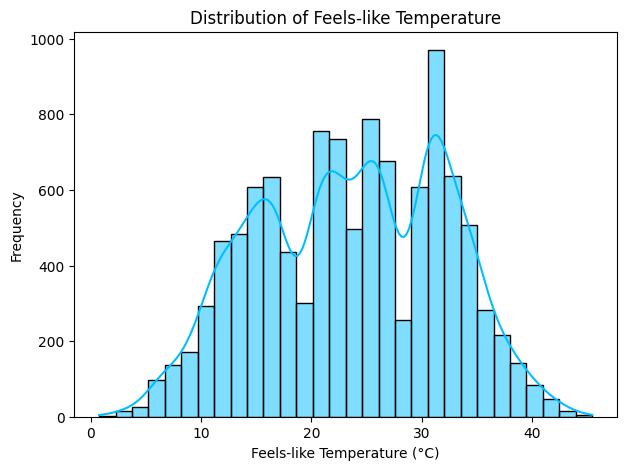

In [11]:
# FEELS LIKE - TEMPERATURE DISTRIBUTION (atemp)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.histplot(x='atemp', data=df, bins=30, kde=True, color='deepskyblue')
plt.xlabel('Feels-like Temperature (°C)')
plt.ylabel('Frequency')
plt.title('Distribution of Feels-like Temperature')
plt.show()

Obswervation: Atemp follows a similar distribution to temperature, indicating strong correlation between actual and perceived temperature.

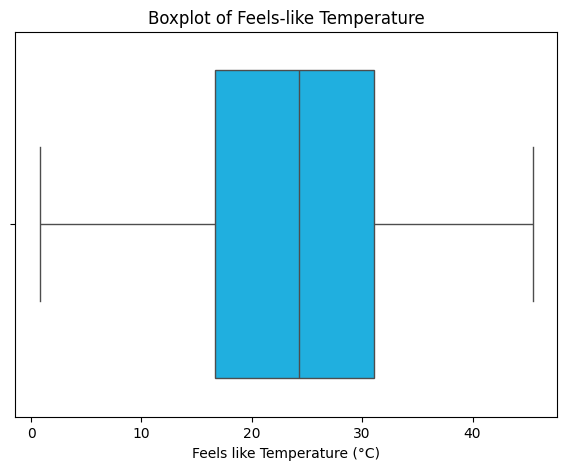

In [10]:
# OUTLIER DETECTION (ATEMP)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.boxplot(x=df['atemp'], color ='deepskyblue')
plt.xlabel('Feels like Temperature (°C)')
plt.title("Boxplot of Feels-like Temperature")
plt.show()

Observation:

1.) Feels-like temperature is centered around ~25°C, with most values between ~18°C and ~31°C, indicating moderate spread.

2.) The range is wide (about ~1°C to ~45°C), showing varying perceived temperatures. The distribution appears fairly symmetric with no notable outliers.

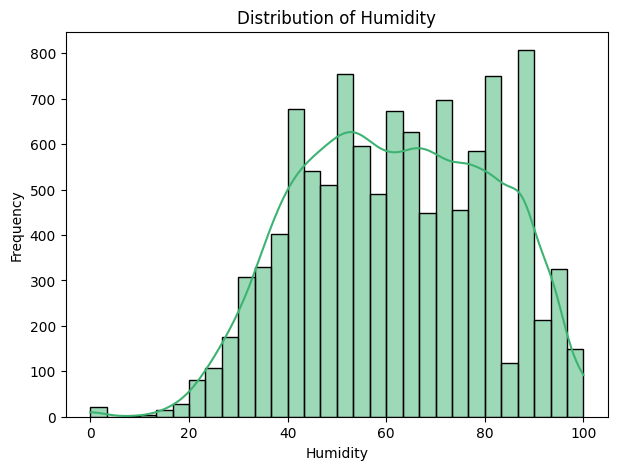

In [12]:
# HUMIDITY DISTRIBUTION
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.histplot(x='humidity', data=df, bins=30, kde=True, color='mediumseagreen')
plt.xlabel('Humidity')
plt.ylabel('Frequency')
plt.title('Distribution of Humidity')
plt.show()

Observation: Humidity values are slightly skewed, with higher frequency in mid to high humidity levels.

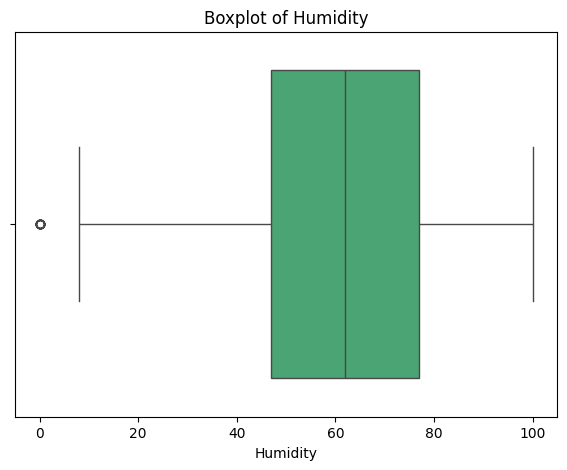

In [12]:
# OUTLIER DETECTION (HUMIDITY)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.boxplot(x=df['humidity'], color = 'mediumseagreen')
plt.xlabel('Humidity')
plt.title('Boxplot of Humidity')
plt.show()

Observation:

1.) Humidity is centered around ~60%, with most values between ~45% and ~80%, showing moderate variability.

2.) The overall range is wide (about 10% to 100%), indicating diverse conditions.
There is a low outlier near 0%, suggesting a rare unusually dry observation.

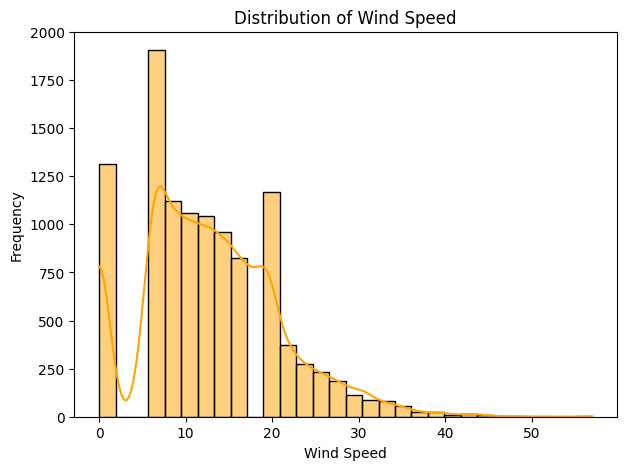

In [13]:
# WINDSPEED DISTRIBUTION
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.histplot(x='windspeed', data=df, bins=30, kde = True, color='orange')
plt.xlabel('Wind Speed')
plt.ylabel('Frequency')
plt.title('Distribution of Wind Speed')
plt.show()

Observation: Windspeed is right-skewed, with most observations at lower wind speeds and very few high wind conditions.

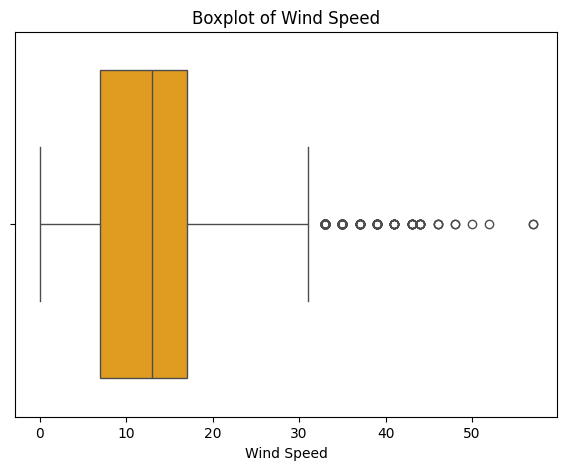

In [14]:
# OUTLIER DETECTION (WINDSPEED)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.boxplot(x=df['windspeed'], color = 'orange')
plt.xlabel('Wind Speed')
plt.title('Boxplot of Wind Speed')
plt.show()

Observation:

1.) Wind speed is centered around ~12–15, with most values between ~7 and ~18, indicating moderate variation.

2.) The distribution is right-skewed, with many high-value outliers extending beyond ~30 up to ~55.
This suggests occasional strong wind events compared to generally lower typical speeds.

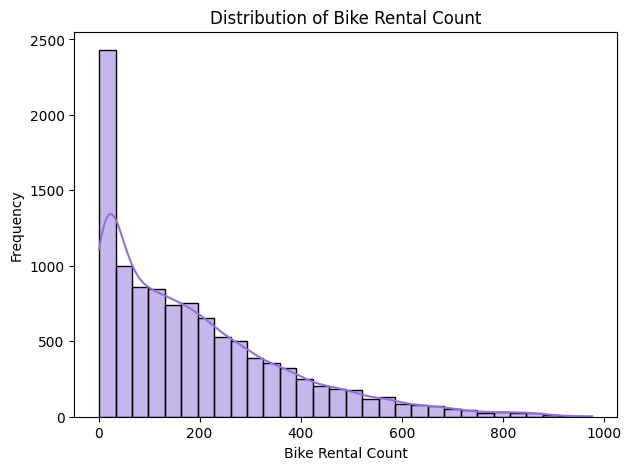

In [15]:
# COUNT DISTRIBUTION (count: count of total rental bikes including both casual and registered)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.histplot(x='count', data=df, bins=30, kde=True, color='mediumpurple')
plt.xlabel('Bike Rental Count')
plt.ylabel('Frequency')
plt.title('Distribution of Bike Rental Count')
plt.show()

Observation: The distribution of bike rentals is right-skewed. This indicates that low rentals are common, while very high rentals occur less frequently but still exist.

Text(0.5, 1.0, 'Boxplot of Bike Rental Count')

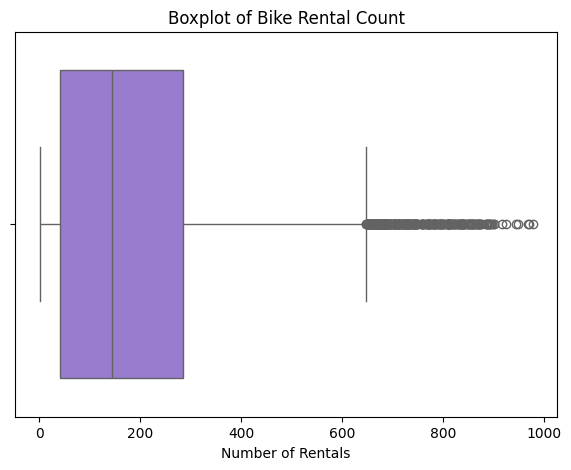

In [ ]:
# OUTLIER DETECTION (COUNT OF TOTAL RENTAL BIKES)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.boxplot(x=df['count'], color = 'mediumpurple')
plt.xlabel('Number of Rentals')
plt.title('Boxplot of Bike Rental Count')

Observation:

1.) Bike rental counts are centered around ~150–200, with most values between ~50 and ~300, showing moderate spread.

2.) The distribution is strongly right-skewed, with many high-value outliers extending beyond ~600 up to ~1000.
This indicates occasional spikes in demand compared to generally lower typical rental counts.

# Bivariate Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

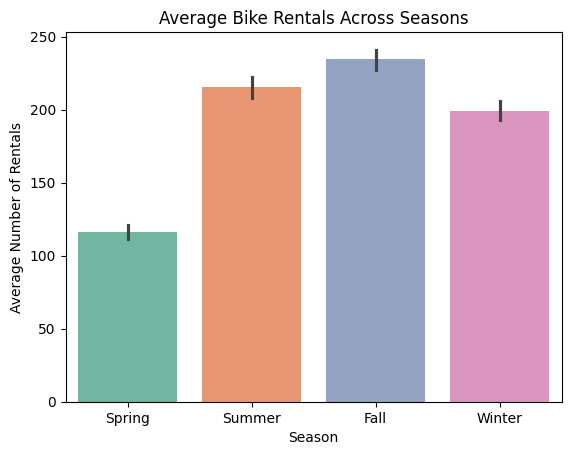

In [ ]:
# SEASON VS BIKE RENTAL COUNT
sns.barplot(x='season_label', y='count', data=df, palette='Set2', hue='season_label', legend=False)
plt.xlabel('Season')
plt.ylabel('Average Number of Rentals')
plt.title('Average Bike Rentals Across Seasons')
plt.show()

In [19]:
df.groupby('season_label')['count'].mean().sort_values(ascending = False)

,count
season_label,
Fall,234.417124
Summer,215.251372
Winter,198.988296
Spring,116.343261


Observation:

1.) Bike rentals are higher in favorable seasons (summer/fall) compared to extreme seasons.

2.) This suggests that season has a noticeable impact on demand.

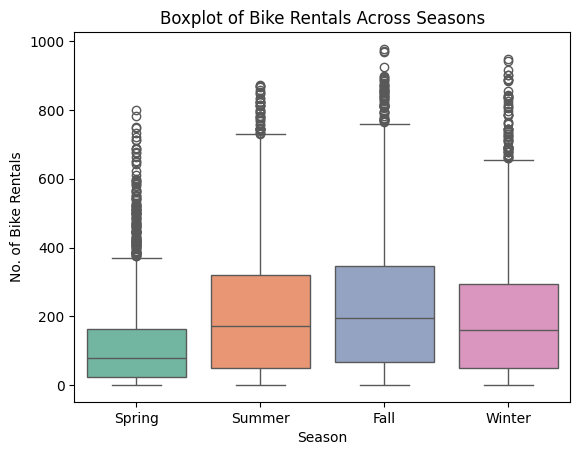

In [ ]:
# SEASON VS BIKE RENTAL COUNT (BOXPLOT)
sns.boxplot(x='season_label', y='count', data= df, palette='Set2', hue='season_label', legend=False)
plt.xlabel('Season')
plt.ylabel('No. of Bike Rentals')
plt.title('Boxplot of Bike Rentals Across Seasons')
plt.show()

Observation:

1.) Bike rentals are highest in Fall, followed by Summer and Winter, and lowest in Spring.

2.) Fall and Summer show higher medians and wider spread, indicating more usage and variability.

3.) Spring has the lowest rentals and smaller spread, suggesting consistently lower demand.
Simple takeaway:

4.) Bike rentals increase in warmer and pleasant seasons (Summer & Fall) and decrease in colder or transitional seasons (Spring).

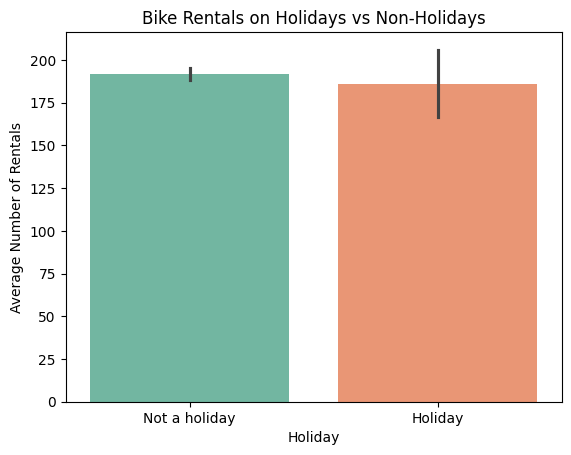

In [ ]:
# HOLIDAY VS COUNT OF BIKE RENTALS
sns.barplot(x='holiday_label', y='count', data=df, palette='Set2', hue='holiday_label', legend=False)
plt.xlabel('Holiday')
plt.ylabel('Average Number of Rentals')
plt.title('Bike Rentals on Holidays vs Non-Holidays')
plt.show()

In [23]:
df.groupby('holiday_label')['count'].mean().sort_values(ascending = False)

,count
holiday_label,
Not a holiday,191.741655
Holiday,185.877814


Observation:

1.) Demand is lower on holidays compared to non-holidays.

2.) This suggests reduced commuting activity on holidays.

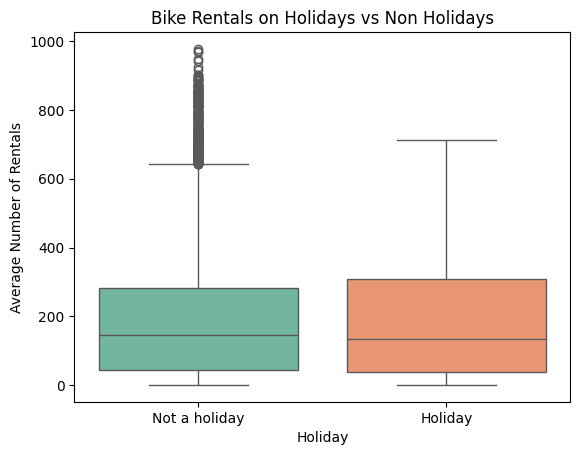

In [ ]:
# HOLIDAY VS BIKE RENTAL COUNT (BOXPLOT)
sns.boxplot(x='holiday_label', y='count', data=df, palette='Set2', hue='holiday_label', legend=False)
plt.xlabel('Holiday')
plt.ylabel('Average Number of Rentals')
plt.title('Bike Rentals on Holidays vs Non Holidays')
plt.show()

Observation:

1.) Median rentals are slightly higher on non-holidays than on holidays.

2.) Non-holidays show more high-value outliers, meaning occasional very high demand days.

3.) Holidays have a similar spread but fewer extreme highs, indicating more consistent but slightly lower usage.

4.) Bike rentals tend to be slightly higher and more variable on non-holidays, likely due to regular commuting patterns.

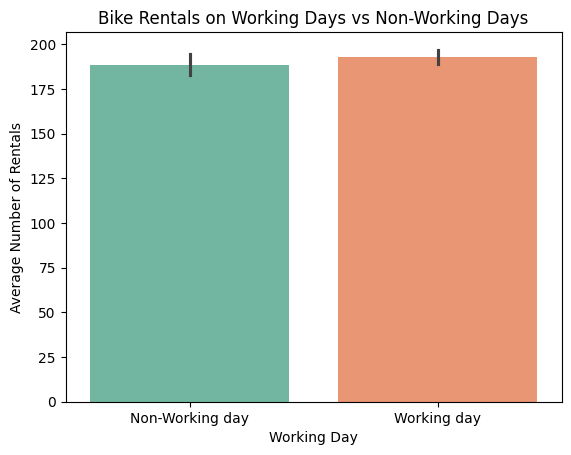

In [ ]:
# WORKING DAY VS BIKE RENTAL COUNT
sns.barplot(x='workingday_label', y='count', data=df, palette='Set2', hue='workingday_label', legend=False)
plt.xlabel('Working Day')
plt.ylabel('Average Number of Rentals')
plt.title('Bike Rentals on Working Days vs Non-Working Days')
plt.show()

In [24]:
df.groupby('workingday_label')['count'].mean().sort_values(ascending = False)

,count
workingday_label,
Working day,193.011873
Non-Working day,188.506621


Observation:

1.) Bike rentals are slightly higher on working days compared to non-working days.

2.) This indicates usage is driven by daily commuting patterns.

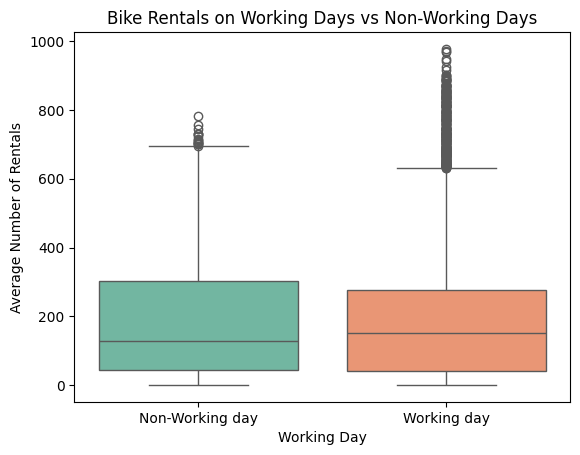

In [ ]:
# WORKING DAY VS BIKE RENTAL COUNT (BOXPLOT)
sns.boxplot(x='workingday_label', y='count', data=df, palette='Set2', hue='workingday_label', legend=False)
plt.xlabel('Working Day')
plt.ylabel('Average Number of Rentals')
plt.title('Bike Rentals on Working Days vs Non-Working Days')
plt.show()

Observation:

1.) Working days have slightly higher median rentals than non-working days.

2.) Working days show more high-value outliers, indicating occasional very high demand.

3.) Non-working days have similar spread but slightly lower overall usage.
Simple takeaway:

4.) Bike rentals are generally higher on working days, likely due to commuting patterns.

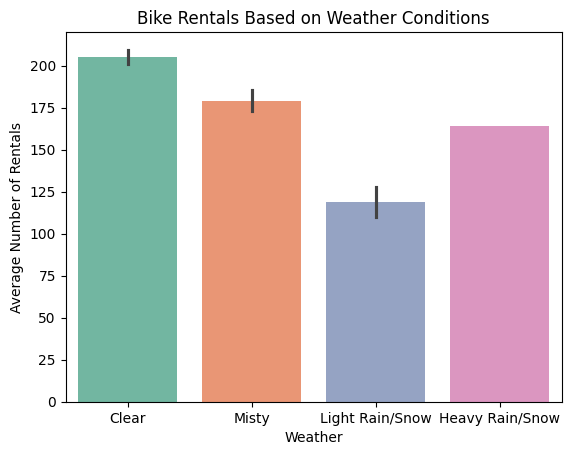

In [ ]:
# WEATHER VS BIKE RENTAL COUNT
sns.barplot(x='weather_label', y='count', data=df, palette='Set2', hue='weather_label', legend=False)
plt.xlabel('Weather')
plt.ylabel('Average Number of Rentals')
plt.title('Bike Rentals Based on Weather Conditions')
plt.show()

In [25]:
df.groupby('weather_label')['count'].mean().sort_values(ascending=False)

,count
weather_label,
Clear,205.236791
Misty,178.955540
Heavy Rain/Snow,164.000000
Light Rain/Snow,118.846333


Observation:

1.) Demand is highest during clear weather and decreases as weather conditions worsen.

2.) Severe weather significantly reduces bike rentals.

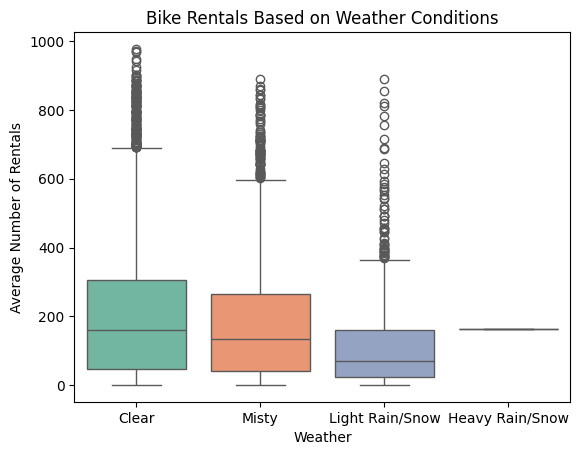

In [ ]:
# WEATHER VS BIKE RENTAL COUNT (BOXPLOT)
sns.boxplot(x='weather_label', y='count', data=df, palette='Set2', hue='weather_label', legend=False)
plt.xlabel('Weather')
plt.ylabel('Average Number of Rentals')
plt.title('Bike Rentals Based on Weather Conditions')
plt.show()

Observation:

1.) Clear weather has the highest median and widest spread, indicating high and variable rentals.

2.) Mist shows slightly lower rentals than clear, but still moderate usage.

3.) Light rain/snow has much lower median, showing reduced demand.

4.)Heavy rain/snow shows almost no spread, indicating very few data points and unreliable pattern.

5.) Bike rentals decrease as weather worsens, but heavy rain results may be misleading due to limited data.

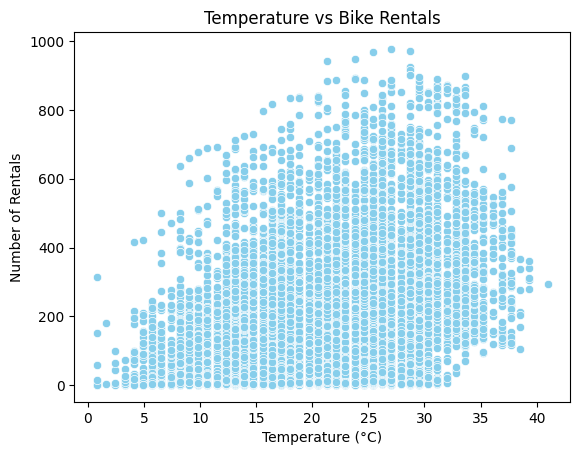

In [ ]:
# TEMPERATURE VS BIKE RENTAL COUNT
sns.scatterplot(x='temp', y='count', data=df, color='skyblue')
plt.title('Temperature vs Bike Rentals')
plt.xlabel('Temperature (°C)')
plt.ylabel('Number of Rentals')
plt.show()

Observation:

1.) Bike rentals tend to increase with temperature up to a certain range.

2.) Extremely low or high temperatures may reduce demand.

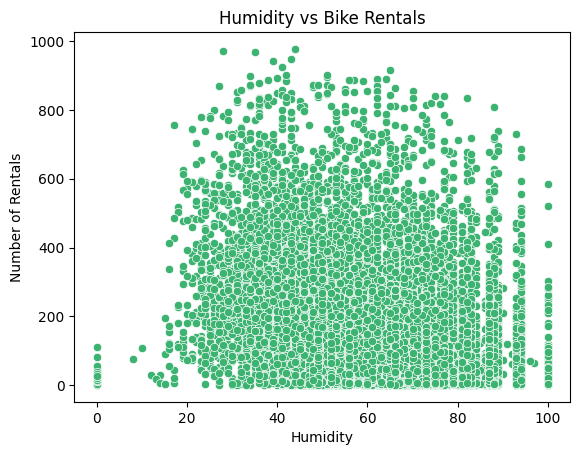

In [ ]:
# HUMIDITY VS BIKE RENTAL COUNT
sns.scatterplot(x='humidity', y='count', data=df, color='mediumseagreen')
plt.xlabel('Humidity')
plt.ylabel('Number of Rentals')
plt.title('Humidity vs Bike Rentals')
plt.show()

Observation:

1.) There is no strong clear relationship between humidity and bike rentals (points are widely scattered).

2.) Rentals occur at almost all humidity levels, especially between ~30% and ~80%.

3.) Demand decreases as conditions become more uncomfortable.

Text(0.5, 1.0, 'Wind Speed vs Bike Rentals')

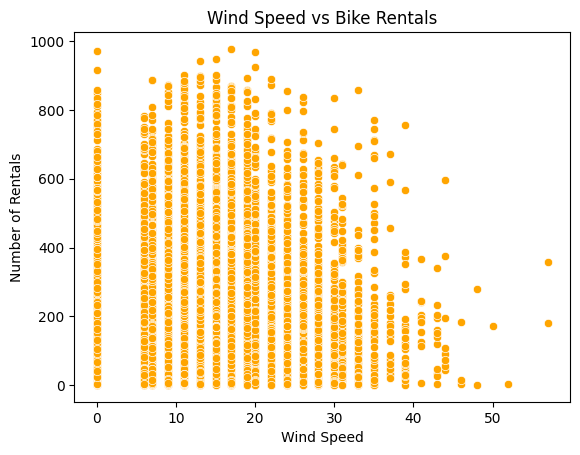

In [ ]:
# WIND SPEED VS BIKE RENTAL COUNT
sns.scatterplot(x='windspeed', y='count', data=df, color='orange')
plt.xlabel('Wind Speed')
plt.ylabel('Number of Rentals')
plt.title('Wind Speed vs Bike Rentals')

Observation:

1.) There is a weak negative relationship between wind speed and bike rentals.

2.) As wind speed increases, higher rental values become less frequent.

3.) Most high rentals occur at low to moderate wind speeds (0–20), while high wind speeds show mostly low rentals.

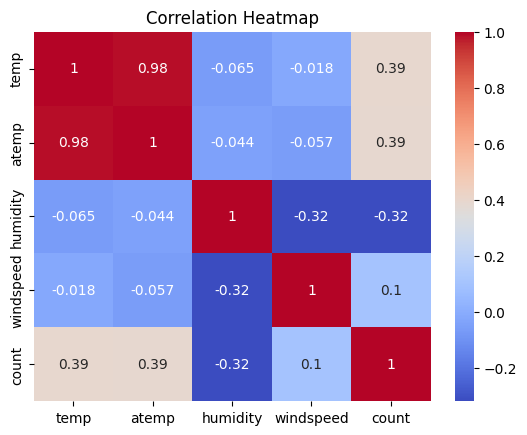

In [ ]:
# CORRELATION HEATMAP
corr = df[['temp', 'atemp', 'humidity', 'windspeed', 'count']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Observation:

1.) Temperature & Feels-like temp (0.98): Very strong positive correlation (almost identical variables).

2.)Bike rentals & temperature (~0.39): Moderate positive relationship, rentals increase with temperature.

3.) Bike rentals & humidity (~-0.32): Moderate negative relationship, higher humidity reduces rentals.

4.) Bike rentals & wind speed (~0.1): Very weak relationship, little to no effect.

Final Insight: Rentals increase in warm weather, decrease with high humidity, and are not strongly affected by wind speed.

# Hypothesis Testing

# Working Day vs Bike Rental Count (2 Sample T- Test)

H0 (Null Hypothesis): Working day has no effect on bike rentals

H1 (Alternative Hypothesis): Working day has an effect on bike rentals

In [ ]:
# PREPARE DATASET
working_day = df[df['workingday'] == 1]['count']
non_working_day = df[df['workingday'] == 0]['count']

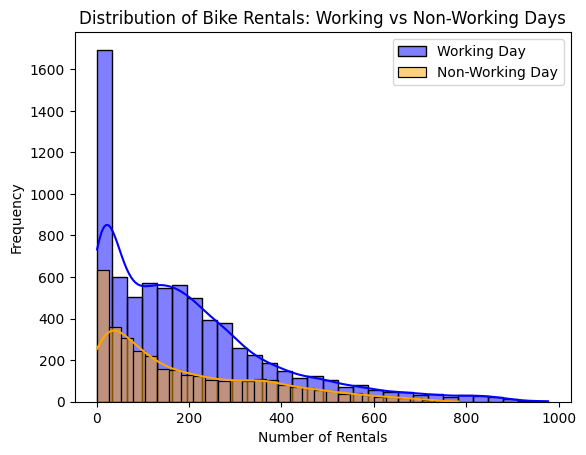

In [ ]:
# CHECK ASSUMPTIONS
# 1.) NORMALITY
sns.histplot(working_day, kde=True, color='blue', label='Working Day', bins=30)
sns.histplot(non_working_day, kde=True, color='orange', label='Non-Working Day', bins=30)
plt.xlabel('Number of Rentals')
plt.ylabel('Frequency')
plt.title('Distribution of Bike Rentals: Working vs Non-Working Days')
plt.legend()
plt.show()

Observation:

1.) Both distributions are right-skewed, indicating that lower rental counts are more frequent. The distribution for working days shows slightly higher rental values compared to non-working days, suggesting increased demand during working days.

2.) The distributions are not perfectly normal (right-skewed), indicating that the normality assumption is not fully satisfied.

In [ ]:
# 2.) CONFIIRMING NORMALITY (SHAPIRO)
from scipy.stats import shapiro
print(shapiro(working_day))
print(shapiro(non_working_day))

ShapiroResult(statistic=np.float64(0.8702545795617624), pvalue=np.float64(2.2521124830019574e-61))
ShapiroResult(statistic=np.float64(0.885211755076074), pvalue=np.float64(4.4728547627911074e-45))


The Shapiro-Wilk test indicates that the data is not normally distributed (p < 0.05)

In [ ]:
# 2. CHECK VARIANCE (LEVENE)
from scipy.stats import levene
stat, p = levene(working, non_working)
print(p)

0.9437823280916695


Observation: Levene’s test shows that the variances of the two groups are equal (p > 0.05).

In [ ]:
# PERFORMING T - TEST
from scipy import stats

t_statistic, p_value = stats.ttest_ind(working_day, non_working_day)

alpha = 0.05 # Significance level

print(f"T-Statistic: {t_statistic:.4f}")
print(f"P-Value: {p_value:.4f}")

if p_value < alpha:
    print("Reject H0: Working day has a significant effect on bike rentals")
else:
    print("Fail to Reject H0: Working day has no significant effect on bike rentals")

T-Statistic: 1.2096
P-Value: 0.2264
Fail to Reject H0: Working day has no significant effect on bike rentals


Observation:

1.) Since the p-value (0.226) is greater than the significance level of 0.05, we fail to reject the null hypothesis. This indicates that there is no statistically significant difference in bike rentals between working days and non-working days

2.) Although the normality assumption is violated, the t-test is robust for large datasets so the results remain reliable.

# Season vs Bike Rental Count (ANOVA)

H0 (Null Hypothesis): The mean bike rental counts are equal across all seasons

H1 (Alternative Hypothesis): At least one season has a different mean bike rental count

In [ ]:
# H0: Season has no significant effect on bike rentals
# H1: Season has a significant effect on bike rentals

In [ ]:
# PREPARE DATASET
spring = df[df['season'] == 1]['count']
summer = df[df['season'] == 2]['count']
fall = df[df['season'] == 3]['count']
winter = df[df['season'] == 4]['count']

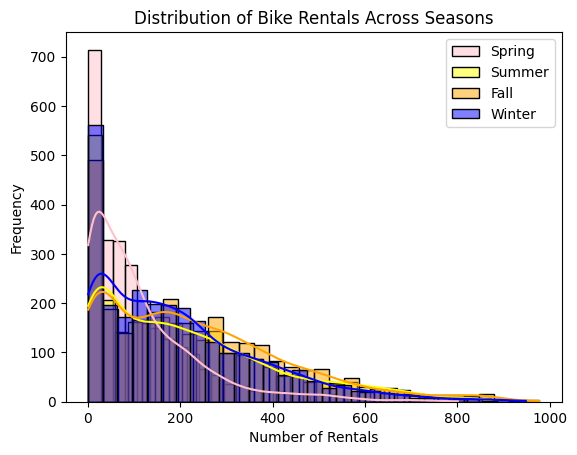

In [ ]:
# CHECK ASSUMPTIONS
# NORMALITY (HISTROGRAM)
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(spring, kde=True, color='pink', label='Spring', bins=30)
sns.histplot(summer, kde=True, color='yellow', label='Summer', bins=30)
sns.histplot(fall, kde=True, color='orange', label='Fall', bins=30)
sns.histplot(winter,kde=True, color='blue', label='Winter', bins=30)
plt.xlabel('Number of Rentals')
plt.ylabel('Frequency')
plt.title('Distribution of Bike Rentals Across Seasons')
plt.legend()
plt.show()

Observation: The distributions of bike rentals across seasons appear right-skewed, indicating non-normality

In [ ]:
# NORMALITY (SHAPIRO)
from scipy.stats import shapiro
print(shapiro(spring))
print(shapiro(summer))
print(shapiro(fall))
print(shapiro(winter))

ShapiroResult(statistic=np.float64(0.8087378401253588), pvalue=np.float64(8.749584618867662e-49))
ShapiroResult(statistic=np.float64(0.9004818080893252), pvalue=np.float64(6.039374406270491e-39))
ShapiroResult(statistic=np.float64(0.9148166372899196), pvalue=np.float64(1.043680518918597e-36))
ShapiroResult(statistic=np.float64(0.8954637482095505), pvalue=np.float64(1.1299244409282836e-39))


Observation: The Shapiro-Wilk test indicates that the data for all seasons is not normally distributed (p < 0.05)

In [ ]:
# VARIANCE (LEVENE TEST)
from scipy.stats import levene
stat, p = levene(spring, summer, fall, winter)
print(p)

1.0147116860043298e-118


Observation: Levene’s test indicates unequal variances across seasons.

In [ ]:
# PERFORMING ANOVA
from scipy.stats import f_oneway
f_stat, p_value = f_oneway(spring, summer, fall, winter)

print(f'F-Statistic: {f_stat:.4f}')
print(f'P-Value: {p_value:.4f}')

alpha = 0.05 #Significance level

if p_value <= alpha:
  print('Reject H0: There is a significant difference in bike rentals across seasons')
else:
  print('Fail to Reject H0: Different seasons have no effect on bike rentals')

F-Statistic: 236.9467
P-Value: 0.0000
Reject H0: There is a significant difference in bike rentals across seasons


Observation:

1.) Since the p-value is less than 0.05, we reject the null hypothesis. This indicates that there is a statistically significant difference in bike rental counts across different seasons.

2.) Although the normality assumption is violated, ANOVA is robust for large datasets, so the results remain reliable.

## Weather vs Bike Rental Count (ANOVA)

H0: Weather does not significantly affect bike rentals

H1: Weather significantly affects bike rentals

In [ ]:
# SEPARATE DATASET
weather1 = df[df['weather'] == 1]['count']
weather2 = df[df['weather'] == 2]['count']
weather3 = df[df['weather'] == 3]['count']
weather4 = df[df['weather'] == 4]['count']

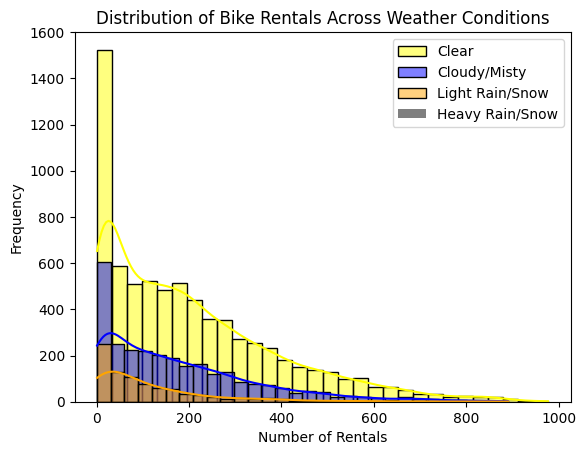

In [ ]:
# CHECK NORMALITY (HISTROGRAM)
sns.histplot(weather1, kde=True, color='yellow', label='Clear', bins=30)
sns.histplot(weather2, kde=True, color='blue', label='Cloudy/Misty', bins=30)
sns.histplot(weather3, kde=True, color='orange', label='Light Rain/Snow', bins=30)
sns.histplot(weather4, kde=True, color='black', label='Heavy Rain/Snow', bins=30)
plt.title('Distribution of Bike Rentals Across Weather Conditions')
plt.xlabel('Number of Rentals')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Observation: The distributions across weather conditions appear right-skewed, indicating non-normality.

In [ ]:
# NORMALITY (SHAPIRO)
from scipy.stats import shapiro
print(shapiro(weather1))
print(shapiro(weather2))
print(shapiro(weather3))
print(shapiro(weather4))

ShapiroResult(statistic=np.float64(0.8909259459740138), pvalue=np.float64(1.5964921477006555e-57))
ShapiroResult(statistic=np.float64(0.8767694973495206), pvalue=np.float64(9.777839106111785e-43))
ShapiroResult(statistic=np.float64(0.7674327906035717), pvalue=np.float64(3.875893017396149e-33))
ShapiroResult(statistic=np.float64(nan), pvalue=np.float64(nan))


/tmp/ipykernel_5077/3755960797.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print(shapiro(weather4))


Observation: Shapiro-Wilk test indicates that the data is not normally distributed across weather conditions (p < 0.05)

In [ ]:
# CHECK VARIANCE (LEVENE TEST)
from scipy.stats import levene
stat, p = levene(weather1, weather2, weather3, weather4)
print('Levene p-value', p)

Levene p-value 3.504937946833238e-35


Observation: Levene’s test indicates unequal variances across weather conditions.

In [ ]:
# PERFORM ANOVA
from scipy.stats import f_oneway
f_stat, p_value = f_oneway(weather1, weather2, weather3, weather4)
print(f'F-Statistic: {f_stat:.4f}')
print(f'P-Value: {p_value:.4f}')

alpha = 0.05 #significance level

if p_value <= alpha:
  print('Reject H0: Weather significantly affects bike rentals')
else:
  print('Fail to Reject H0: Weather does not significantly affect bike rentals')

F-Statistic: 65.5302
P-Value: 0.0000
Reject H0: Weather significantly affects bike rentals


Observation:

1.) Bike rental demand varies significantly across different weather conditions.

2.) Although normality assumption is violated, ANOVA is robust for large datasets, so the results remain reliable.

# Weather vs Season (Chi -Square Test)

H0: Weather and season are independent (no relationship)

H1: Weather and season are dependent (there is a relationship)

In [ ]:
# CREATE CONTINGENCY TABLE
import pandas as pd
contingency_table = pd.crosstab(df['season'], df['weather'])
print(contingency_table)

weather     1    2    3  4
season                    
1        1759  715  211  1
2        1801  708  224  0
3        1930  604  199  0
4        1702  807  225  0


Observation: A contingency table is created to observe the frequency distribution between season and weather categories.

In [ ]:
# PERFORM CHI - SQUARE TEST
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f'Chi-Square Statistic: {chi2:.4f}')
print(f'P-Value: {p:.4f}')

alpha = 0.05 #significance level

if p <= alpha:
  print('Reject H0: Weather and season are dependent')
else:
  print('Fail to Reject H0: Weather and season are independent')

Chi-Square Statistic: 49.1587
P-Value: 0.0000
Reject H0: Weather and season are dependent


Observation:

1.) Weather conditions vary significantly across seasons, indicating a strong dependency between season and weather

2.) Chi-square test assumptions are satisfied as both variables are categorical.

# Business Insights:

**1.) Weather Significantly Affects Demand:**

Bike rentals are highest during clear weather and decrease as weather worsens.
Severe weather conditions (rain, snow, fog) lead to a sharp decline in demand.

**Business Insight:**
Weather is one of the strongest drivers of bike rental demand.

**2.) Working Day Has No Significant Effect:**

No statistically significant difference was found between working and non-working days.

**Business Insight:**
Bike usage is not limited to office commuting, it is also used for leisure and other purposes.

**3.) Temperature Positively Influences Demand:**

Rentals increase with temperature up to a comfortable range.
Extremely high or low temperatures reduce demand.

Business Insight:
There exists an optimal temperature range for maximum usage.

**5.) Humidity Negatively Affects Rentals:**

Higher humidity levels are associated with lower demand.

**Business Insight:**
Uncomfortable weather conditions discourage bike usage.

**6.) Windspeed Has Minimal Impact:**

Windspeed shows weak or negligible relationship with rentals.

**Business Insight:**
Windspeed is not a major factor affecting user decisions.

**7.) Weather and Season Are Dependent:**
Strong relationship found between weather and season.

**Business Insight:**
Season indirectly affects demand through weather conditions.

# Final Conclusion:

The demand for Yulu electric cycles is primarily influenced by environmental factors such as weather and season, while working day does not have a significant impact. Favorable weather conditions and moderate temperatures lead to higher rentals, whereas extreme weather reduces demand. Therefore, demand patterns are driven more by comfort and external conditions rather than purely by commuting needs.

# Business Recommendations

**1.) Dynamic Bike Allocation:**

i) Increase bike availability during:
- Good weather
- Peak seasons

ii) Reduce supply during low-demand conditions

**2.) Weather-Based Pricing Strategy:**

i) Offer discounts during: Rainy or harsh weather

ii) Maintain premium pricing during high-demand periods

**3.) Seasonal Marketing Campaigns:**

Promote usage during:
- Summer / pleasant seasons
- Run offers in low-demand seasons

**4.) Real-Time Demand Prediction:**

Use weather forecasts to:
- Predict demand
- Optimize operations

**5.) Improve User Comfort:**

Provide:
- Weather-resistant bikes
- Rain gear / accessories